In [ ]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv(r"/content/fiat500.csv")

In [ ]:
data.head(20)

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
0,1,lounge,51,882,25000,1,44.907242,8.611560,8900
1,2,pop,51,1186,32500,1,45.666359,12.241890,8800
2,3,sport,74,4658,142228,1,45.503300,11.417840,4200
3,4,lounge,51,2739,160000,1,40.633171,17.634609,6000
4,5,pop,73,3074,106880,1,41.903221,12.495650,5700
5,6,pop,74,3623,70225,1,45.000702,7.682270,7900
6,7,lounge,51,731,11600,1,44.907242,8.611560,10750
7,8,lounge,51,1521,49076,1,41.903221,12.495650,9190
8,9,sport,73,4049,76000,1,45.548000,11.549470,5600
9,10,sport,51,3653,89000,1,45.438301,10.991700,6000


In [ ]:
data.describe()

,ID,engine_power,age_in_days,km,previous_owners,lat,lon,price
count,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000
mean,768.854605,51.915132,1657.190789,53602.474342,1.123684,43.539485,11.571552,8564.311842
std,443.599478,4.010360,1290.870689,40181.202940,0.415901,2.137960,2.332344,1942.771619
min,1.000000,51.000000,366.000000,1232.000000,1.000000,36.855839,7.245400,2500.000000
25%,383.750000,51.000000,670.000000,20000.000000,1.000000,41.794763,9.505090,7100.000000
50%,769.500000,51.000000,1066.000000,39162.000000,1.000000,44.394096,11.869260,9000.000000
75%,1151.250000,51.000000,2623.750000,80000.000000,1.000000,45.467960,12.786127,10000.000000
max,1538.000000,77.000000,4658.000000,235000.000000,4.000000,46.795612,18.365520,11100.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               1520 non-null   int64  
 1   model            1520 non-null   object 
 2   engine_power     1520 non-null   int64  
 3   age_in_days      1520 non-null   int64  
 4   km               1520 non-null   int64  
 5   previous_owners  1520 non-null   int64  
 6   lat              1520 non-null   float64
 7   lon              1520 non-null   float64
 8   price            1520 non-null   int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 107.0+ KB


In [ ]:
data.shape

(1520, 9)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data1=data.drop(['lat','lon'],axis=1)

In [ ]:
data.groupby(['model',"km",'price']).count()

ID  engine_power  age_in_days  previous_owners  lat  lon
model  km     price                                                          
lounge 1232   9900    1             1            1                1    1    1
       2790   10400   1             1            1                1    1    1
       3600   9490    1             1            1                1    1    1
       4000   9500    1             1            1                1    1    1
       5140   9500    1             1            1                1    1    1
...                  ..           ...          ...              ...  ...  ...
sport  175000 4800    1             1            1                1    1    1
       177000 5400    1             1            1                1    1    1
       185000 4400    1             1            1                1    1    1
       188000 4490    1             1            1                1    1    1
       190000 3800    1             1            1                1    1    1

[1431 rows x 6 columns]

In [ ]:
data1.isnull().sum()

,0
ID,0
model,0
engine_power,0
age_in_days,0
km,0
previous_owners,0
price,0


In [ ]:
data["model"].unique()

array(['lounge', 'pop', 'sport'], dtype=object)

In [ ]:
#FIRST 20 ROWS AND COLUMNS
data1.head(20)

,ID,model,engine_power,age_in_days,km,previous_owners,price
0,1,lounge,51,882,25000,1,8900
1,2,pop,51,1186,32500,1,8800
2,3,sport,74,4658,142228,1,4200
3,4,lounge,51,2739,160000,1,6000
4,5,pop,73,3074,106880,1,5700
5,6,pop,74,3623,70225,1,7900
6,7,lounge,51,731,11600,1,10750
7,8,lounge,51,1521,49076,1,9190
8,9,sport,73,4049,76000,1,5600
9,10,sport,51,3653,89000,1,6000


In [ ]:
#CORRELATION
corr_matrix = data1.corr(numeric_only=True)

print(corr_matrix)

NameError: name 'data1' is not defined

In [ ]:
#CORRELATION HEATMAP
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,

            annot=True,

            cmap='coolwarm',

            fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

NameError: name 'corr_matrix' is not defined

<Figure size 1000x800 with 0 Axes>

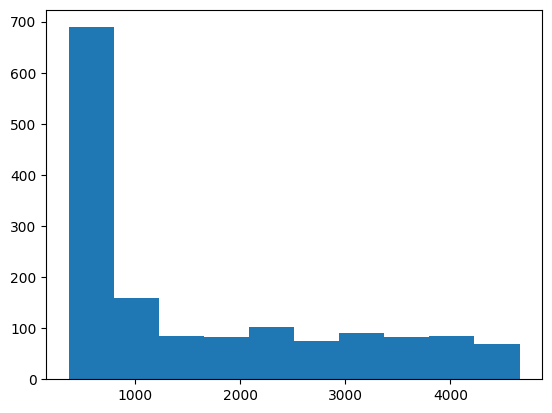

In [ ]:
# HISTOGRAM
plt.hist(data['age_in_days'])
plt.show()


In [ ]:
#ENCODE THE MODEL
data1['model'] = data1['model'].map({'lounge': 1, 'pop': 2, 'sport': 3})


In [ ]:
#SPLIT DATASET
Y=data1["price"]
X=data1.drop(["price"],axis=1)


In [ ]:
#TRAINING =80%
#TESTING=20%
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42
)

In [ ]:
#MODEL SELECTION AND FIR
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X_train,Y_train)

LinearRegression()

In [ ]:
#PREDICTION USING PREDICT FUNC
Y_pred = reg.predict(X_test)

In [ ]:

Result =pd.DataFrame(columns=['Price',"Predicted"])
Result['Price']=Y_test
Result['Predicted']=Y_pred
Result=Result.reset_index()
Result["Id"]=Result.index
Result.head(10)

,Price,Predicted,Id
461,9980,9699.141964,461
1314,9600,9883.818324,1314
1472,6800,6687.326196,1472
744,9890,10266.616630,744
247,10500,9195.874752,247
430,7950,6782.498559,430
939,9490,9713.865729,939
1490,9950,10038.090406,1490
358,8579,9672.808143,358
427,9450,9487.484078,427


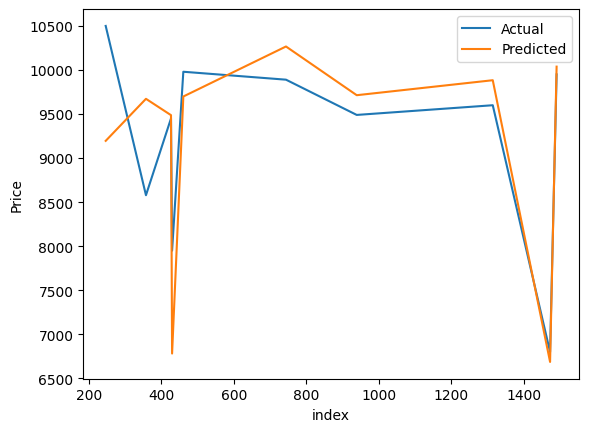

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x='index', y='Price', data=Result.head(10), label='Actual')
sns.lineplot(x='index', y='Predicted', data=Result.head(10), label='Predicted')

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error as mape
mape_value=mape(Y_test,Y_pred)
mape_value

605.1140372143254

In [ ]:
ab=9
print(ab**.5)

3.0


In [ ]:
from sklearn.metrics import mean_squared_error
t=mean_squared_error(Y_test,Y_pred)
print(t**.5)

791.5250692311998


In [ ]:
new=[[51,2197,70000,1,0,0],[51,3127,100000,0,2,0],[51,5227,175000,0,0,3]]
price =reg.predict(new)
price

array([ 457274.50393817,  650775.67788614, 1174231.36299082])

In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(Y_test, Y_pred))
print("MSE:", mean_squared_error(Y_test, Y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))
print("R2 Score:", r2_score(Y_test, Y_pred))

MAE: 605.1140372143254
MSE: 626511.9352214556
RMSE: 791.5250692311998
R2 Score: 0.8413694985427453


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, Y_pred)
print("R2 Score:", r2)

accuracy = r2 * 100
print("Accuracy:", accuracy, "%")

R2 Score: 0.8413694985427453
Accuracy: 84.13694985427453 %
